# LangGraph - Conditional Graphs

> Introduction to Dynamic Routing

To implement dynamic routing in a LangGraph workflow, we can design a *conditional execution path* based on runtime data.

Let’s explore how to build a simple flow that decides between addition and subtraction depending on the input state.

We’ll start by defining a state that holds the numbers, the operation to perform (+ or -), and a placeholder for the result.

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Define the structure of the state the graph will work with
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    result: int

We have two operations:

In [2]:
# Addition logic
def add(state: AgentState) -> AgentState:
    state["result"] = state["number1"] + state["number2"]
    return state

# Subtraction logic
def subtract(state: AgentState) -> AgentState:
    state["result"] = state["number1"] - state["number2"]
    return state

In a conditional graph, we need to choose between multiple paths depending on the data. The `decide_operation` **examines the state and returns a label** that identifies which path the graph should follow.

In [3]:
# Decision router that returns which path to take
def decide_operation(state: AgentState) -> str:
    if state["operation"] == "+":
        return "add_operation"
    elif state["operation"] == "-":
        return "subtract_operation"

We create the graph and add its operation nodes. The `START` node serves as a `router`; it is effectively a no-op node that evaluates a decision function to choose the next path. The `lambda` function simply preserves the state until that decision is made.

In [4]:
# Create a graph that can work with AgentState
graph = StateGraph(AgentState)

# Register processing nodes
graph.add_node("add_node", add)
graph.add_node("subtract_node", subtract)
graph.add_node("router", lambda state: state)  # a placeholder router node

# Start from the router node
graph.add_edge(START, "router")

`graph.add_conditional_edges(...)` method allows us to create **branches** in the graph: depending on the data in the state, the graph will **follow one of several possible edges** from the given node — in this case, from `"router"`.

In [5]:
# Conditional routing from router node based on operation
graph.add_conditional_edges(
    "router",
    decide_operation,
    {
        "add_operation": "add_node",
        "subtract_operation": "subtract_node"
    }
)

# Define endpoints
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

# Compile the graph into an executable app
app = graph.compile()

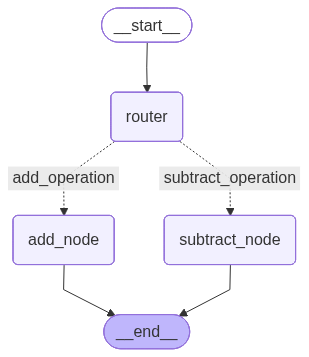

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

Sample runs:

In [7]:
initial_state_1 = AgentState(number1=5, number2=3, operation="+", result=0)
print(app.invoke(initial_state_1))

{'number1': 5, 'number2': 3, 'operation': '+', 'result': 8}


In [8]:
initial_state_2 = AgentState(number1=5, number2=3, operation="-", result=0)
print(app.invoke(initial_state_2))

{'number1': 5, 'number2': 3, 'operation': '-', 'result': 2}


This design showcases how LangGraph supports decision-making mid-execution — allowing workflows to adapt their behavior based on the input state. It’s a clean and scalable pattern for building logic-driven applications.